# Growth Table Regression — тестова проба

Тук използваме таблица с растеж по месеци.

Идеята е:

1. да въведем данните от таблицата
2. да оставим празните полета като липсващи стойности
3. да превърнем диапазоните в числа
4. да използваме regression, за да предвидим липсващите клетки
5. да сравним реални и predicted стойности

Това е учебна проба, не точна ветеринарна прогноза.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
data = pd.DataFrame({
    "month": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],

    "height_withers_cm": [
        "22-27", "33-40", "43-49", "50-56", "55-60", "58-64",
        "60-66", "62-68", "64-69", "65-70", "65-70", "65-71"
    ],

    "body_length_cm": [
        "25-30", "37-44", "47-54", "55-62", "61-66", "64-71",
        "66-73", "68-75", "71-76", "72-77", "72-77", "72-78"
    ],

    "pastern_circumference_cm": [
        "8-10", "10-12", "11-12.5", "11.5-13", "12-13.5", "12-14",
        "12-14", None, None, None, None, None
    ],

    "front_leg_length_cm": [
        "11-16", "18-25", "24-30", "28-34", "31-36", "33-38",
        "34-39", "34.5-39.5", "35-40", None, None, None
    ],

    "chest_circumference_cm": [
        "36-45", "47-55", "55-62", "60-69", "65-74", "69-78",
        "71-81", "74-83", "75-85", "75-86", "78-88", "80-89"
    ],

    "head_length_cm": [
        "12-15", "16-19", "19.5-22.5", "22-25", "24-27", "25-28",
        "26-29", "26.5-29.5", "27-30", None, None, None
    ],

    "muzzle_length_cm": [
        "4-6", "6-8", "7-10", "9-11", "10-12.5", "11-13.5",
        "11.5-14", "12-15", None, None, None, None
    ],

    "weight_kg": [
        "3-4", "8-10", "12-14", "15-18", "20-23", "25-28",
        "30-33", "35-43", None, None, None, None
    ]
})

data

,month,height_withers_cm,body_length_cm,pastern_circumference_cm,front_leg_length_cm,chest_circumference_cm,head_length_cm,muzzle_length_cm,weight_kg
0,1,22-27,25-30,8-10,11-16,36-45,12-15,4-6,3-4
1,2,33-40,37-44,10-12,18-25,47-55,16-19,6-8,8-10
2,3,43-49,47-54,11-12.5,24-30,55-62,19.5-22.5,7-10,12-14
3,4,50-56,55-62,11.5-13,28-34,60-69,22-25,9-11,15-18
4,5,55-60,61-66,12-13.5,31-36,65-74,24-27,10-12.5,20-23
5,6,58-64,64-71,12-14,33-38,69-78,25-28,11-13.5,25-28
6,7,60-66,66-73,12-14,34-39,71-81,26-29,11.5-14,30-33
7,8,62-68,68-75,NaN,34.5-39.5,74-83,26.5-29.5,12-15,35-43
8,9,64-69,71-76,NaN,35-40,75-85,27-30,NaN,NaN
9,10,65-70,72-77,NaN,NaN,75-86,NaN,NaN,NaN


In [2]:
def parse_range(value):
    if value is None:
        return np.nan, np.nan, np.nan

    value = str(value).replace(",", ".").strip()

    if value == "" or value == "-":
        return np.nan, np.nan, np.nan

    parts = value.split("-")

    if len(parts) == 2:
        low = float(parts[0])
        high = float(parts[1])
        mid = (low + high) / 2
        return low, high, mid

    number = float(value)
    return number, number, number

In [3]:
numeric_data = data[["month"]].copy()

measurement_columns = [
    "height_withers_cm",
    "body_length_cm",
    "pastern_circumference_cm",
    "front_leg_length_cm",
    "chest_circumference_cm",
    "head_length_cm",
    "muzzle_length_cm",
    "weight_kg"
]

for column in measurement_columns:
    lows = []
    highs = []
    mids = []

    for value in data[column]:
        low, high, mid = parse_range(value)
        lows.append(low)
        highs.append(high)
        mids.append(mid)

    numeric_data[column + "_low"] = lows
    numeric_data[column + "_high"] = highs
    numeric_data[column + "_mid"] = mids

numeric_data

,month,height_withers_cm_low,height_withers_cm_high,height_withers_cm_mid,body_length_cm_low,body_length_cm_high,body_length_cm_mid,pastern_circumference_cm_low,pastern_circumference_cm_high,pastern_circumference_cm_mid,...,chest_circumference_cm_mid,head_length_cm_low,head_length_cm_high,head_length_cm_mid,muzzle_length_cm_low,muzzle_length_cm_high,muzzle_length_cm_mid,weight_kg_low,weight_kg_high,weight_kg_mid
0,1,22.0,27.0,24.5,25.0,30.0,27.5,8.0,10.0,9.00,...,40.5,12.0,15.0,13.5,4.0,6.0,5.00,3.0,4.0,3.5
1,2,33.0,40.0,36.5,37.0,44.0,40.5,10.0,12.0,11.00,...,51.0,16.0,19.0,17.5,6.0,8.0,7.00,8.0,10.0,9.0
2,3,43.0,49.0,46.0,47.0,54.0,50.5,11.0,12.5,11.75,...,58.5,19.5,22.5,21.0,7.0,10.0,8.50,12.0,14.0,13.0
3,4,50.0,56.0,53.0,55.0,62.0,58.5,11.5,13.0,12.25,...,64.5,22.0,25.0,23.5,9.0,11.0,10.00,15.0,18.0,16.5
4,5,55.0,60.0,57.5,61.0,66.0,63.5,12.0,13.5,12.75,...,69.5,24.0,27.0,25.5,10.0,12.5,11.25,20.0,23.0,21.5
5,6,58.0,64.0,61.0,64.0,71.0,67.5,12.0,14.0,13.00,...,73.5,25.0,28.0,26.5,11.0,13.5,12.25,25.0,28.0,26.5
6,7,60.0,66.0,63.0,66.0,73.0,69.5,12.0,14.0,13.00,...,76.0,26.0,29.0,27.5,11.5,14.0,12.75,30.0,33.0,31.5
7,8,62.0,68.0,65.0,68.0,75.0,71.5,NaN,NaN,NaN,...,78.5,26.5,29.5,28.0,12.0,15.0,13.50,35.0,43.0,39.0
8,9,64.0,69.0,66.5,71.0,76.0,73.5,NaN,NaN,NaN,...,80.0,27.0,30.0,28.5,NaN,NaN,NaN,NaN,NaN,NaN
9,10,65.0,70.0,67.5,72.0,77.0,74.5,NaN,NaN,NaN,...,80.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
completed_data = data.copy()

for column in measurement_columns:
    low_column = column + "_low"
    high_column = column + "_high"

    known_rows = numeric_data[low_column].notna() & numeric_data[high_column].notna()
    missing_rows = numeric_data[low_column].isna() | numeric_data[high_column].isna()

    known_months = numeric_data.loc[known_rows, "month"]

    known_low = numeric_data.loc[known_rows, low_column]
    known_high = numeric_data.loc[known_rows, high_column]

    missing_months = numeric_data.loc[missing_rows, "month"]

    if len(known_months) >= 2 and len(missing_months) > 0:
        low_a, low_b = np.polyfit(known_months, known_low, 1)
        high_a, high_b = np.polyfit(known_months, known_high, 1)

        predicted_low = low_a * missing_months + low_b
        predicted_high = high_a * missing_months + high_b

        for index, low_value, high_value in zip(missing_months.index, predicted_low, predicted_high):
            completed_data.loc[index, column] = f"{low_value:.1f}-{high_value:.1f} predicted"

completed_data

,month,height_withers_cm,body_length_cm,pastern_circumference_cm,front_leg_length_cm,chest_circumference_cm,head_length_cm,muzzle_length_cm,weight_kg
0,1,22-27,25-30,8-10,11-16,36-45,12-15,4-6,3-4
1,2,33-40,37-44,10-12,18-25,47-55,16-19,6-8,8-10
2,3,43-49,47-54,11-12.5,24-30,55-62,19.5-22.5,7-10,12-14
3,4,50-56,55-62,11.5-13,28-34,60-69,22-25,9-11,15-18
4,5,55-60,61-66,12-13.5,31-36,65-74,24-27,10-12.5,20-23
5,6,58-64,64-71,12-14,33-38,69-78,25-28,11-13.5,25-28
6,7,60-66,66-73,12-14,34-39,71-81,26-29,11.5-14,30-33
7,8,62-68,68-75,13.4-15.1 predicted,34.5-39.5,74-83,26.5-29.5,12-15,35-43
8,9,64-69,71-76,14.0-15.8 predicted,35-40,75-85,27-30,14.0-16.9 predicted,38.8-44.9 predicted
9,10,65-70,72-77,14.6-16.4 predicted,41.8-46.5 predicted,75-86,31.0-34.0 predicted,15.1-18.1 predicted,43.2-50.1 predicted


In [5]:
predicted_only = completed_data.copy()

for column in measurement_columns:
    predicted_only[column] = [
        value if "predicted" in str(value) else ""
        for value in completed_data[column]
    ]

predicted_only

,month,height_withers_cm,body_length_cm,pastern_circumference_cm,front_leg_length_cm,chest_circumference_cm,head_length_cm,muzzle_length_cm,weight_kg
0,1,,,,,,,,
1,2,,,,,,,,
2,3,,,,,,,,
3,4,,,,,,,,
4,5,,,,,,,,
5,6,,,,,,,,
6,7,,,,,,,,
7,8,,,13.4-15.1 predicted,,,,,
8,9,,,14.0-15.8 predicted,,,,14.0-16.9 predicted,38.8-44.9 predicted
9,10,,,14.6-16.4 predicted,41.8-46.5 predicted,,31.0-34.0 predicted,15.1-18.1 predicted,43.2-50.1 predicted


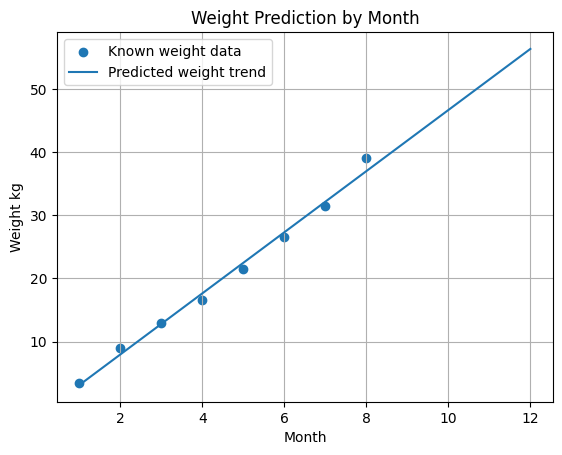

Weight regression formula:
weight = 4.84 * month + -1.71


In [6]:
weight_low = numeric_data["weight_kg_low"]
weight_high = numeric_data["weight_kg_high"]
weight_mid = numeric_data["weight_kg_mid"]

known_rows = weight_mid.notna()
missing_rows = weight_mid.isna()

known_months = numeric_data.loc[known_rows, "month"]
known_weight_mid = numeric_data.loc[known_rows, "weight_kg_mid"]

a, b = np.polyfit(known_months, known_weight_mid, 1)

all_months = numeric_data["month"]
predicted_weight_mid = a * all_months + b

plt.scatter(known_months, known_weight_mid, label="Known weight data")
plt.plot(all_months, predicted_weight_mid, label="Predicted weight trend")

plt.title("Weight Prediction by Month")
plt.xlabel("Month")
plt.ylabel("Weight kg")
plt.grid(True)
plt.legend()

plt.show()

print("Weight regression formula:")
print(f"weight = {a:.2f} * month + {b:.2f}")

In [7]:
known_prediction = a * known_months + b
mse = np.mean((known_weight_mid - known_prediction) ** 2)

print("Weight MSE:", mse)

Weight MSE: 1.0792410714285725


In [8]:
# TEST CELL

# 1. Проверяваме дали completed_data съществува
assert "completed_data" in globals(), "completed_data не е създадена"

# 2. Проверяваме дали има predicted стойности
predicted_count = 0

for column in measurement_columns:
    predicted_count += completed_data[column].astype(str).str.contains("predicted").sum()

assert predicted_count > 0, "Няма попълнени predicted стойности"

# 3. Проверяваме дали таблицата има 12 месеца
assert len(completed_data) == 12, "Таблицата трябва да има 12 реда"

# 4. Проверяваме дали месеците са от 1 до 12
assert completed_data["month"].tolist() == list(range(1, 13)), "Месеците трябва да са от 1 до 12"

print("Tests passed")
print("Predicted values count:", predicted_count)

Tests passed
Predicted values count: 19


Regression formula:
weight = 4.84 * month + -1.71


,Month,Predicted weight kg
8,9,41.839286
9,10,46.678571
10,11,51.517857
11,12,56.357143


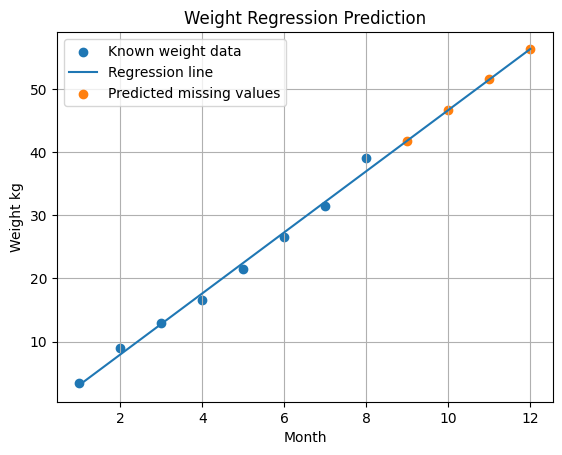

MSE: 1.0792410714285725


In [9]:
# REGRESSION EXAMPLE — Weight prediction

weight_mid = numeric_data["weight_kg_mid"]

known_rows = weight_mid.notna()
missing_rows = weight_mid.isna()

known_months = numeric_data.loc[known_rows, "month"]
known_weights = numeric_data.loc[known_rows, "weight_kg_mid"]

missing_months = numeric_data.loc[missing_rows, "month"]

# Това е самата регресия
a, b = np.polyfit(known_months, known_weights, 1)

# Формула на модела
print("Regression formula:")
print(f"weight = {a:.2f} * month + {b:.2f}")

# Предикция за всички месеци
all_months = numeric_data["month"]
predicted_weights = a * all_months + b

# Предикция само за празните месеци
predicted_missing_weights = a * missing_months + b

predicted_table = pd.DataFrame({
    "Month": missing_months,
    "Predicted weight kg": predicted_missing_weights
})

display(predicted_table)

# Графика
plt.scatter(known_months, known_weights, label="Known weight data")
plt.plot(all_months, predicted_weights, label="Regression line")
plt.scatter(missing_months, predicted_missing_weights, label="Predicted missing values")

plt.title("Weight Regression Prediction")
plt.xlabel("Month")
plt.ylabel("Weight kg")
plt.grid(True)
plt.legend()
plt.show()

# MSE
known_prediction = a * known_months + b
mse = np.mean((known_weights - known_prediction) ** 2)

print("MSE:", mse)

,Month,Average predicted kg,Large dog predicted kg,Very large dog predicted kg
0,1,3.125000,3.593750,4.062500
1,2,7.964286,9.158929,10.353571
2,3,12.803571,14.724107,16.644643
3,4,17.642857,20.289286,22.935714
4,5,22.482143,25.854464,29.226786
5,6,27.321429,31.419643,35.517857
6,7,32.160714,36.984821,41.808929
7,8,37.000000,42.550000,48.100000
8,9,41.839286,48.115179,54.391071
9,10,46.678571,53.680357,60.682143


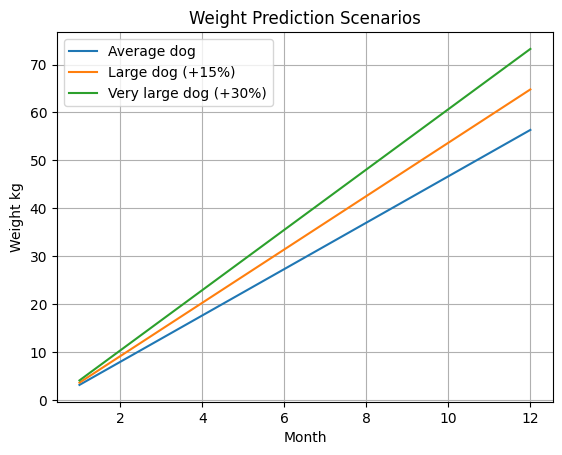

In [10]:
# Larger / heavier dog scenarios

average_weight = predicted_weights

large_weight = predicted_weights * 1.15       # 15% по-тежко
very_large_weight = predicted_weights * 1.30  # 30% по-тежко

scenario_table = pd.DataFrame({
    "Month": all_months,
    "Average predicted kg": average_weight,
    "Large dog predicted kg": large_weight,
    "Very large dog predicted kg": very_large_weight
})

display(scenario_table)

plt.plot(all_months, average_weight, label="Average dog")
plt.plot(all_months, large_weight, label="Large dog (+15%)")
plt.plot(all_months, very_large_weight, label="Very large dog (+30%)")

plt.title("Weight Prediction Scenarios")
plt.xlabel("Month")
plt.ylabel("Weight kg")
plt.grid(True)
plt.legend()

plt.show()

In [11]:
# Check if dog is above predicted average

dog_month = 8
dog_weight = 47

predicted_average = a * dog_month + b

difference = dog_weight - predicted_average

print("Dog month:", dog_month)
print("Dog weight:", dog_weight)
print("Predicted average weight:", predicted_average)
print("Difference:", difference)

if difference > 0:
    print("This dog is heavier than the predicted average.")
else:
    print("This dog is lighter than or equal to the predicted average.")

Dog month: 8
Dog weight: 47
Predicted average weight: 37.0
Difference: 10.0
This dog is heavier than the predicted average.


,Месец,Средно прогнозно тегло кг,Едро куче кг (+15%),Много едро куче кг (+30%)
0,1,3.125000,3.593750,4.062500
1,2,7.964286,9.158929,10.353571
2,3,12.803571,14.724107,16.644643
3,4,17.642857,20.289286,22.935714
4,5,22.482143,25.854464,29.226786
5,6,27.321429,31.419643,35.517857
6,7,32.160714,36.984821,41.808929
7,8,37.000000,42.550000,48.100000
8,9,41.839286,48.115179,54.391071
9,10,46.678571,53.680357,60.682143


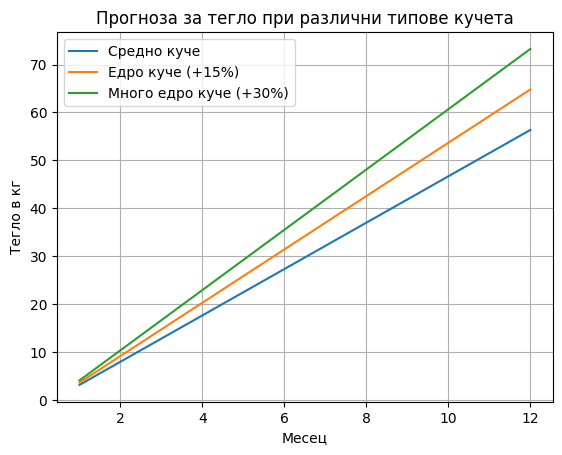

In [12]:
# Сценарии за по-тежки кучета

средно_тегло = predicted_weights

едро_куче = predicted_weights * 1.15        # 15% по-тежко от средното
много_едро_куче = predicted_weights * 1.30  # 30% по-тежко от средното

таблица_сценарии = pd.DataFrame({
    "Месец": all_months,
    "Средно прогнозно тегло кг": средно_тегло,
    "Едро куче кг (+15%)": едро_куче,
    "Много едро куче кг (+30%)": много_едро_куче
})

display(таблица_сценарии)

plt.plot(all_months, средно_тегло, label="Средно куче")
plt.plot(all_months, едро_куче, label="Едро куче (+15%)")
plt.plot(all_months, много_едро_куче, label="Много едро куче (+30%)")

plt.title("Прогноза за тегло при различни типове кучета")
plt.xlabel("Месец")
plt.ylabel("Тегло в кг")
plt.grid(True)
plt.legend()

plt.show()

In [13]:
# Проверка на конкретно куче

месец_на_кучето = 8
реално_тегло = 47

прогнозно_средно_тегло = a * месец_на_кучето + b
разлика = реално_тегло - прогнозно_средно_тегло

print("Месец на кучето:", месец_на_кучето)
print("Реално тегло:", реално_тегло, "кг")
print("Прогнозно средно тегло:", прогнозно_средно_тегло, "кг")
print("Разлика:", разлика, "кг")

if разлика > 0:
    print("Кучето е по-тежко от средната прогноза.")
elif разлика < 0:
    print("Кучето е по-леко от средната прогноза.")
else:
    print("Кучето е точно около средната прогноза.")

Месец на кучето: 8
Реално тегло: 47 кг
Прогнозно средно тегло: 37.0 кг
Разлика: 10.0 кг
Кучето е по-тежко от средната прогноза.


,Месец,Долна прогноза кг,Средна прогноза кг,Горна прогноза кг
0,1,2.75,3.125000,3.500000
1,2,7.25,7.964286,8.678571
2,3,11.75,12.803571,13.857143
3,4,16.25,17.642857,19.035714
4,5,20.75,22.482143,24.214286
5,6,25.25,27.321429,29.392857
6,7,29.75,32.160714,34.571429
7,8,34.25,37.000000,39.750000
8,9,38.75,41.839286,44.928571
9,10,43.25,46.678571,50.107143


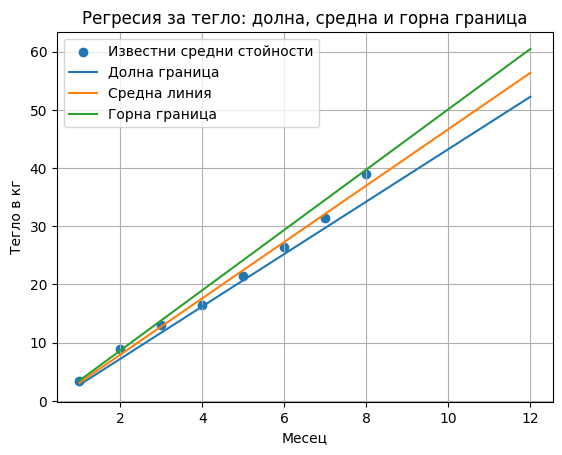

In [14]:
# Регресия с долна, средна и горна граница за тегло

weight_low = numeric_data["weight_kg_low"]
weight_high = numeric_data["weight_kg_high"]
weight_mid = numeric_data["weight_kg_mid"]

known_rows = weight_mid.notna()

known_months = numeric_data.loc[known_rows, "month"]
known_low = numeric_data.loc[known_rows, "weight_kg_low"]
known_mid = numeric_data.loc[known_rows, "weight_kg_mid"]
known_high = numeric_data.loc[known_rows, "weight_kg_high"]

all_months = numeric_data["month"]

# Регресия за долна, средна и горна граница
low_a, low_b = np.polyfit(known_months, known_low, 1)
mid_a, mid_b = np.polyfit(known_months, known_mid, 1)
high_a, high_b = np.polyfit(known_months, known_high, 1)

predicted_low = low_a * all_months + low_b
predicted_mid = mid_a * all_months + mid_b
predicted_high = high_a * all_months + high_b

таблица_диапазони = pd.DataFrame({
    "Месец": all_months,
    "Долна прогноза кг": predicted_low,
    "Средна прогноза кг": predicted_mid,
    "Горна прогноза кг": predicted_high
})

display(таблица_диапазони)

plt.scatter(known_months, known_mid, label="Известни средни стойности")
plt.plot(all_months, predicted_low, label="Долна граница")
plt.plot(all_months, predicted_mid, label="Средна линия")
plt.plot(all_months, predicted_high, label="Горна граница")

plt.title("Регресия за тегло: долна, средна и горна граница")
plt.xlabel("Месец")
plt.ylabel("Тегло в кг")
plt.grid(True)
plt.legend()

plt.show()

,Месец,Женско долна кг,Женско средна кг,Женско горна кг,Мъжко долна кг,Мъжко средна кг,Мъжко горна кг
0,1,2.75,2.937500,3.125000,3.125000,3.312500,3.500000
1,2,7.25,7.607143,7.964286,7.964286,8.321429,8.678571
2,3,11.75,12.276786,12.803571,12.803571,13.330357,13.857143
3,4,16.25,16.946429,17.642857,17.642857,18.339286,19.035714
4,5,20.75,21.616071,22.482143,22.482143,23.348214,24.214286
5,6,25.25,26.285714,27.321429,27.321429,28.357143,29.392857
6,7,29.75,30.955357,32.160714,32.160714,33.366071,34.571429
7,8,34.25,35.625000,37.000000,37.000000,38.375000,39.750000
8,9,38.75,40.294643,41.839286,41.839286,43.383929,44.928571
9,10,43.25,44.964286,46.678571,46.678571,48.392857,50.107143


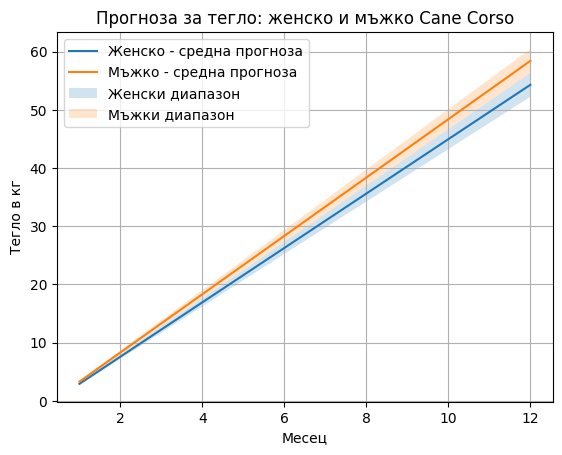

In [15]:
# Прогноза за тегло: женско и мъжко куче

женско_долна = predicted_low
женско_средна = (predicted_low + predicted_mid) / 2
женско_горна = predicted_mid

мъжко_долна = predicted_mid
мъжко_средна = (predicted_mid + predicted_high) / 2
мъжко_горна = predicted_high

таблица_пол = pd.DataFrame({
    "Месец": all_months,

    "Женско долна кг": женско_долна,
    "Женско средна кг": женско_средна,
    "Женско горна кг": женско_горна,

    "Мъжко долна кг": мъжко_долна,
    "Мъжко средна кг": мъжко_средна,
    "Мъжко горна кг": мъжко_горна
})

display(таблица_пол)

plt.plot(all_months, женско_средна, label="Женско - средна прогноза")
plt.plot(all_months, мъжко_средна, label="Мъжко - средна прогноза")

plt.fill_between(all_months, женско_долна, женско_горна, alpha=0.2, label="Женски диапазон")
plt.fill_between(all_months, мъжко_долна, мъжко_горна, alpha=0.2, label="Мъжки диапазон")

plt.title("Прогноза за тегло: женско и мъжко Cane Corso")
plt.xlabel("Месец")
plt.ylabel("Тегло в кг")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Проверка на конкретно куче според пол

пол = "мъжко"   
месец = 8
реално_тегло = 47

if пол == "женско":
    долна = женско_долна[месец - 1]
    средна = женско_средна[месец - 1]
    горна = женско_горна[месец - 1]
else:
    долна = мъжко_долна[месец - 1]
    средна = мъжко_средна[месец - 1]
    горна = мъжко_горна[месец - 1]

print("Пол:", пол)
print("Месец:", месец)
print("Реално тегло:", реално_тегло, "кг")
print("Прогнозен диапазон:", round(долна, 1), "-", round(горна, 1), "кг")
print("Средна прогноза:", round(средна, 1), "кг")

if реално_тегло < долна:
    print("Кучето е под прогнозния диапазон.")
elif реално_тегло > горна:
    print("Кучето е над прогнозния диапазон.")
else:
    print("Кучето е в прогнозния диапазон.")

Пол: мъжко
Месец: 8
Реално тегло: 47 кг
Прогнозен диапазон: 37.0 - 39.8 кг
Средна прогноза: 38.4 кг
Кучето е над прогнозния диапазон.


## Къде може да се използва регресията?

Регресията може да се използва като помощен инструмент за анализ и прогноза.

В пример с Cane Corso тя може да помага за:

1. попълване на липсващи стойности в таблица
2. прогнозиране на тегло и размери по месеци
3. сравнение на конкретно куче с очакван диапазон
4. отделни прогнози за мъжки и женски
5. визуална графика на растежа
6. откриване на стойности, които са много над или под очакваното

Важно: това е математически ориентир, не ветеринарна диагноза и не финална оценка на кучето.